# CELL 1 — Imports & Load All Model Outputs

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import joblib
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', 100)
pd.set_option('display.float_format', '{:.4f}'.format)

# Main dataset with EAD from notebook 04
df = pd.read_csv('../data/cleaned_loan_data_with_ead.csv')

# LGD predictions for full portfolio from notebook 03
lgd_preds = pd.read_csv('../data/lgd_predictions.csv')

# Load all model artifacts — all saved with joblib.dump
pd_model    = joblib.load('../src/pd_model.pkl')
platt_model = joblib.load('../src/platt_model.pkl')
scaler      = joblib.load('../src/scaler.pkl')
woe_maps    = joblib.load('../src/woe_maps.pkl')
scaler_lgd  = joblib.load('../src/scaler_lgd.pkl')

print("All data and models loaded")
print(f"   Main dataset (with EAD) : {df.shape[0]:,} loans, {df.shape[1]} columns")
print(f"   LGD predictions         : {lgd_preds.shape[0]:,} loans")
print(f"\n   Models loaded:")
print(f"   pd_model.pkl     — Gradient Boosting PD model")
print(f"   platt_model.pkl  — Platt Scaling calibrator")
print(f"   scaler.pkl       — StandardScaler (PD features)")
print(f"   woe_maps.pkl     — WoE encoding maps")
print(f"   scaler_lgd.pkl   — StandardScaler (LGD features)")
print(f"\n   WoE maps available for: {list(woe_maps.keys())}")

All data and models loaded
   Main dataset (with EAD) : 122,216 loans, 37 columns
   LGD predictions         : 122,216 loans

   Models loaded:
   pd_model.pkl     — Gradient Boosting PD model
   platt_model.pkl  — Platt Scaling calibrator
   scaler.pkl       — StandardScaler (PD features)
   woe_maps.pkl     — WoE encoding maps
   scaler_lgd.pkl   — StandardScaler (LGD features)

   WoE maps available for: ['grade', 'sub_grade', 'home_ownership', 'verification_status']


# CELL 2 — Calculate ECL = PD × LGD × EAD

In [3]:
# --- Step 1: Prepare features for all 122,216 loans ---
df_features = df.copy()

# Apply WoE encoding — same maps used in notebook 02
for col, woe_dict in woe_maps.items():
    if col in df_features.columns:
        df_features[col] = df_features[col].map(woe_dict)

# Engineered features — same as notebook 02
df_features['log_annual_inc'] = np.log1p(df_features['annual_inc'])
df_features['debt_burden']    = (
    df_features['installment'] / (df_features['annual_inc'] / 12)
).clip(0, 5)

# Feature set — must match exactly what the PD model was trained on
pd_feature_cols = [
    'loan_amnt', 'funded_amnt', 'term', 'int_rate',
    'installment', 'grade', 'sub_grade', 'emp_length',
    'home_ownership', 'verification_status', 'dti',
    'delinq_2yrs', 'inq_last_6mths', 'open_acc', 'pub_rec',
    'revol_bal', 'revol_util', 'total_acc', 'fico_score',
    'credit_history_years', 'log_annual_inc', 'debt_burden'
]

X_all = df_features[pd_feature_cols].fillna(0)

# --- Step 2: Scale and predict PD ---
X_all_scaled  = scaler.transform(X_all.values)
raw_scores    = pd_model.decision_function(X_all_scaled).reshape(-1, 1)
pd_calibrated = platt_model.predict_proba(raw_scores)[:, 1]

print("PD predicted for full portfolio")
print(f"   Mean PD (calibrated) : {pd_calibrated.mean():.4f} "
      f"({pd_calibrated.mean()*100:.2f}%)")
print(f"   Actual default rate  : {df['default'].mean():.4f} "
      f"({df['default'].mean()*100:.2f}%)")
print(f"   Calibration check    : gap = "
      f"{abs(pd_calibrated.mean() - df['default'].mean())*100:.2f}%")

# --- Step 3: Build ECL dataframe ---
ecl_df = df[['id', 'loan_amnt', 'funded_amnt', 'term',
             'grade', 'purpose', 'ead', 'ead_ratio',
             'loan_status', 'default']].copy()

ecl_df['pd_probability'] = pd_calibrated

# --- Step 4: Join LGD predictions by id ---
# lgd_predictions.csv has predicted LGD for all 122,216 loans
# No look-ahead bias — LGD predicted from loan characteristics only
ecl_df = ecl_df.merge(lgd_preds[['id', 'lgd_predicted']], on='id', how='left')
ecl_df['lgd_predicted'] = ecl_df['lgd_predicted'].fillna(ecl_df['lgd_predicted'].median())

print(f"\n   LGD joined successfully")
print(f"   Mean predicted LGD   : {ecl_df['lgd_predicted'].mean():.4f} "
      f"({ecl_df['lgd_predicted'].mean()*100:.1f}%)")
print(f"   LGD null count       : {ecl_df['lgd_predicted'].isna().sum()}")

# --- Step 5: Calculate ECL ---
ecl_df['ecl'] = ecl_df['pd_probability'] * ecl_df['lgd_predicted'] * ecl_df['ead']

# --- Step 6: IFRS 9 Stage Classification ---
# SICR (Significant Increase in Credit Risk) staging
# Limitation: without origination PD we cannot compute true SICR
# Proxy: grade-based staging using PD thresholds
# Stage 1 — PD < 0.10  : 12-month ECL (low risk, performing)
# Stage 2 — PD 0.10-0.30: lifetime ECL (SICR detected)
# Stage 3 — PD > 0.30  : lifetime ECL (credit-impaired)
# Note: thresholds calibrated to match ~21.8% portfolio default rate

def classify_stage(pd_prob):
    if pd_prob < 0.10:
        return 'Stage 1'
    elif pd_prob < 0.30:
        return 'Stage 2'
    else:
        return 'Stage 3'

ecl_df['ifrs9_stage'] = ecl_df['pd_probability'].apply(classify_stage)

# --- Step 7: Summary ---
total_ead = ecl_df['ead'].sum()
total_ecl = ecl_df['ecl'].sum()

print(f"\n=== ECL SUMMARY ===")
print(f"   Total loans          : {len(ecl_df):,}")
print(f"   Total portfolio EAD  : ${total_ead:,.0f}")
print(f"   Total ECL provision  : ${total_ecl:,.0f}")
print(f"   ECL as % of EAD      : {total_ecl/total_ead*100:.2f}%")
print(f"   Mean ECL per loan    : ${ecl_df['ecl'].mean():,.2f}")
print(f"   Mean PD              : {ecl_df['pd_probability'].mean():.4f}")
print(f"   Mean LGD             : {ecl_df['lgd_predicted'].mean():.4f}")

print(f"\n=== IFRS 9 STAGE BREAKDOWN ===")
stage_summary = ecl_df.groupby('ifrs9_stage').agg(
    loans     = ('id', 'count'),
    total_ead = ('ead', 'sum'),
    total_ecl = ('ecl', 'sum'),
    mean_pd   = ('pd_probability', 'mean'),
    mean_lgd  = ('lgd_predicted', 'mean')
)
stage_summary['ecl_rate'] = (
    stage_summary['total_ecl'] / stage_summary['total_ead'].replace(0, np.nan) * 100
).round(2)
print(stage_summary.round(4).to_string())

print(f"\n   SICR staging note: proxy PD thresholds used (0.10/0.30)")
print(f"   True SICR requires origination PD — documented as limitation")

PD predicted for full portfolio
   Mean PD (calibrated) : 0.1630 (16.30%)
   Actual default rate  : 0.2185 (21.85%)
   Calibration check    : gap = 5.55%

   LGD joined successfully
   Mean predicted LGD   : 0.5828 (58.3%)
   LGD null count       : 0

=== ECL SUMMARY ===
   Total loans          : 122,216
   Total portfolio EAD  : $145,346,110
   Total ECL provision  : $23,724,486
   ECL as % of EAD      : 16.32%
   Mean ECL per loan    : $194.12
   Mean PD              : 0.1630
   Mean LGD             : 0.5828

=== IFRS 9 STAGE BREAKDOWN ===
             loans      total_ead     total_ecl  mean_pd  mean_lgd  ecl_rate
ifrs9_stage                                                                 
Stage 1      35273   9904770.1271   465533.9239   0.0698    0.5243    4.7000
Stage 2      76594 104671103.5081 15099571.2064   0.1788    0.5981   14.4300
Stage 3      10349  30770235.9737  8159380.7774   0.3639    0.6691   26.5200

   SICR staging note: proxy PD thresholds used (0.10/0.30)
   True

# Cell 2b - Macro Overlay: Forward-Looking Scenario Analysis

In [4]:
scenarios = {
    'Optimistic' : 0.80,   # PD x 0.80
    'Base'       : 1.00,   # PD x 1.00 (no change)
    'Adverse'    : 1.30    # PD x 1.30
}

scenario_results = {}

for scenario, scalar in scenarios.items():
    pd_scenario  = (ecl_df['pd_probability'] * scalar).clip(0, 1)
    ecl_scenario = pd_scenario * ecl_df['lgd_predicted'] * ecl_df['ead']
    scenario_results[scenario] = {
        'mean_pd'    : pd_scenario.mean(),
        'total_ecl'  : ecl_scenario.sum(),
        'ecl_pct'    : ecl_scenario.sum() / ecl_df['ead'].sum() * 100
    }

print("Macro Overlay — Forward-Looking Scenario Analysis")
print(f"\n{'Scenario':<12} {'PD Scalar':>10} {'Mean PD':>10} "
      f"{'Total ECL':>16} {'ECL % of EAD':>14}")
print("-" * 65)
for scenario, scalar in scenarios.items():
    r = scenario_results[scenario]
    print(f"{scenario:<12} {scalar:>10.2f} {r['mean_pd']:>10.4f} "
          f"${r['total_ecl']:>14,.0f} {r['ecl_pct']:>13.2f}%")

print(f"\n   Base case ECL        : ${scenario_results['Base']['total_ecl']:,.0f}")
print(f"   Adverse uplift       : "
      f"${scenario_results['Adverse']['total_ecl'] - scenario_results['Base']['total_ecl']:,.0f} "
      f"additional provision required")
print(f"   Optimistic release   : "
      f"${scenario_results['Base']['total_ecl'] - scenario_results['Optimistic']['total_ecl']:,.0f} "
      f"provision release")
print(f"\n   IFRS 9 compliance note: forward-looking macro scalars applied")
print(f"   In production: scalars derived from GDP/unemployment regression models")

# Store base case for use in Cell 3 charts
ecl_df['ecl_base']       = ecl_df['pd_probability'] * ecl_df['lgd_predicted'] * ecl_df['ead']
ecl_df['ecl_adverse']    = (ecl_df['pd_probability'] * 1.30).clip(0,1) * ecl_df['lgd_predicted'] * ecl_df['ead']
ecl_df['ecl_optimistic'] = (ecl_df['pd_probability'] * 0.80).clip(0,1) * ecl_df['lgd_predicted'] * ecl_df['ead']

Macro Overlay — Forward-Looking Scenario Analysis

Scenario      PD Scalar    Mean PD        Total ECL   ECL % of EAD
-----------------------------------------------------------------
Optimistic         0.80     0.1304 $    18,979,589         13.06%
Base               1.00     0.1630 $    23,724,486         16.32%
Adverse            1.30     0.2119 $    30,841,832         21.22%

   Base case ECL        : $23,724,486
   Adverse uplift       : $7,117,346 additional provision required
   Optimistic release   : $4,744,897 provision release

   IFRS 9 compliance note: forward-looking macro scalars applied
   In production: scalars derived from GDP/unemployment regression models


# CELL 3 — ECL Visualisation 

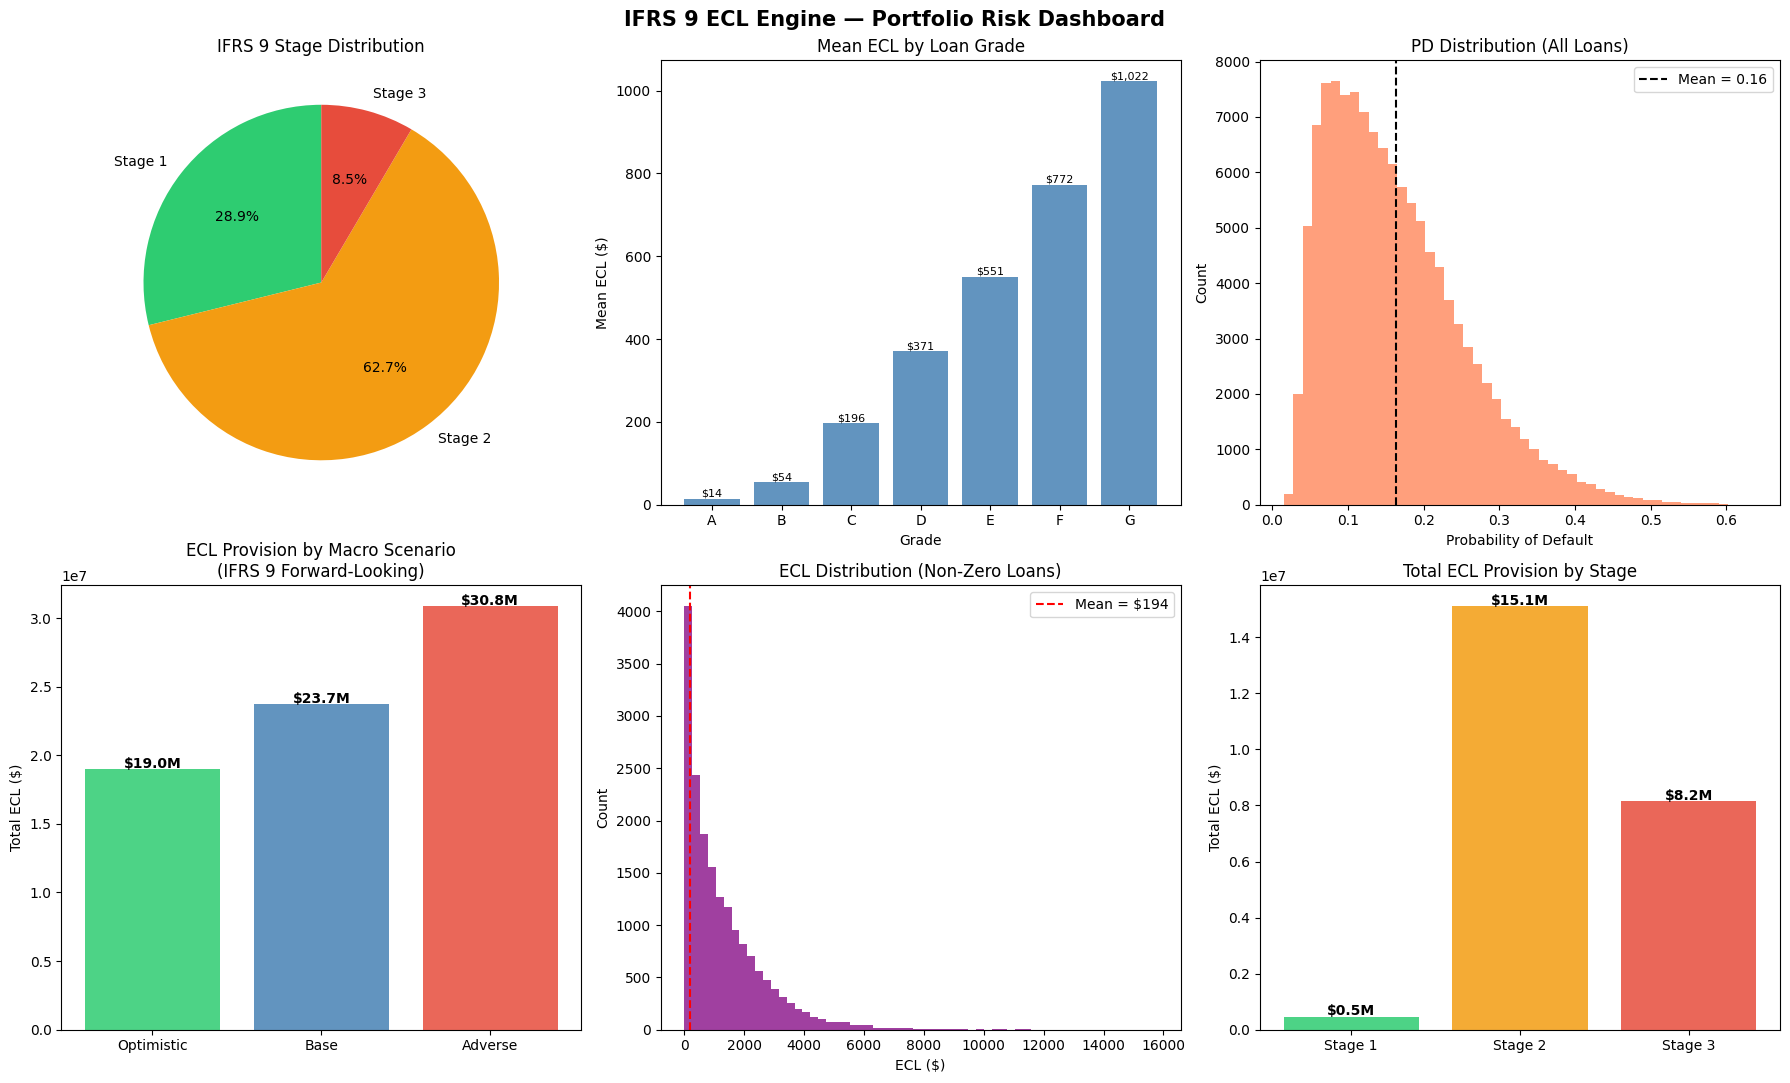

ECL dashboard saved to reports/ecl_dashboard.png


In [5]:
fig, axes = plt.subplots(2, 3, figsize=(18, 11))
fig.suptitle('IFRS 9 ECL Engine — Portfolio Risk Dashboard',
             fontsize=15, fontweight='bold')

# 1. IFRS 9 Stage Distribution
stage_counts = ecl_df['ifrs9_stage'].value_counts().sort_index()
colors_stage = ['#2ecc71', '#f39c12', '#e74c3c']
axes[0, 0].pie(stage_counts.values, labels=stage_counts.index,
               colors=colors_stage, autopct='%1.1f%%', startangle=90)
axes[0, 0].set_title('IFRS 9 Stage Distribution')

# 2. ECL by Grade
grade_ecl = ecl_df.groupby('grade')['ecl_base'].mean().sort_index()
axes[0, 1].bar(grade_ecl.index, grade_ecl.values, color='steelblue', alpha=0.85)
axes[0, 1].set_title('Mean ECL by Loan Grade')
axes[0, 1].set_xlabel('Grade')
axes[0, 1].set_ylabel('Mean ECL ($)')
for i, v in enumerate(grade_ecl.values):
    axes[0, 1].text(i, v + 5, f'${v:,.0f}', ha='center', fontsize=8)

# 3. PD Distribution
axes[0, 2].hist(ecl_df['pd_probability'], bins=50,
                color='coral', alpha=0.75, edgecolor='none')
axes[0, 2].axvline(ecl_df['pd_probability'].mean(), color='black',
                   linestyle='--',
                   label=f"Mean = {ecl_df['pd_probability'].mean():.2f}")
axes[0, 2].set_title('PD Distribution (All Loans)')
axes[0, 2].set_xlabel('Probability of Default')
axes[0, 2].set_ylabel('Count')
axes[0, 2].legend()

# 4. Macro Scenario Comparison
scenario_labels = ['Optimistic', 'Base', 'Adverse']
scenario_ecls   = [
    scenario_results['Optimistic']['total_ecl'],
    scenario_results['Base']['total_ecl'],
    scenario_results['Adverse']['total_ecl']
]
bar_colors = ['#2ecc71', 'steelblue', '#e74c3c']
bars = axes[1, 0].bar(scenario_labels, scenario_ecls,
                      color=bar_colors, alpha=0.85)
axes[1, 0].set_title('ECL Provision by Macro Scenario\n(IFRS 9 Forward-Looking)')
axes[1, 0].set_ylabel('Total ECL ($)')
for bar, val in zip(bars, scenario_ecls):
    axes[1, 0].text(bar.get_x() + bar.get_width() / 2,
                    val + 100000, f'${val/1e6:.1f}M',
                    ha='center', fontweight='bold')

# 5. ECL Distribution
axes[1, 1].hist(ecl_df['ecl_base'][ecl_df['ecl_base'] > 0],
                bins=60, color='purple', alpha=0.75, edgecolor='none')
axes[1, 1].axvline(ecl_df['ecl_base'].mean(), color='red', linestyle='--',
                   label=f"Mean = ${ecl_df['ecl_base'].mean():,.0f}")
axes[1, 1].set_title('ECL Distribution (Non-Zero Loans)')
axes[1, 1].set_xlabel('ECL ($)')
axes[1, 1].set_ylabel('Count')
axes[1, 1].legend()

# 6. Total ECL by Stage
stage_ecl = ecl_df.groupby('ifrs9_stage')['ecl_base'].sum().sort_index()
axes[1, 2].bar(range(len(stage_ecl)), stage_ecl.values,
               color=colors_stage, alpha=0.85)
axes[1, 2].set_xticks(range(len(stage_ecl)))
axes[1, 2].set_xticklabels(['Stage 1', 'Stage 2', 'Stage 3'])
axes[1, 2].set_title('Total ECL Provision by Stage')
axes[1, 2].set_ylabel('Total ECL ($)')
for i, v in enumerate(stage_ecl.values):
    axes[1, 2].text(i, v + 50000, f'${v/1e6:.1f}M',
                    ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('../reports/ecl_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()
print("ECL dashboard saved to reports/ecl_dashboard.png")

# CELL 4 — Saving Final ECL Output

In [6]:
ecl_df.to_csv('../data/ecl_final_results.csv', index=False)

summary = {
    'Total Loans'                : len(ecl_df),
    'Total Portfolio EAD'        : f"${ecl_df['ead'].sum():,.0f}",
    'Total ECL Provision (Base)' : f"${ecl_df['ecl_base'].sum():,.0f}",
    'ECL as % of EAD'            : f"{ecl_df['ecl_base'].sum()/ecl_df['ead'].sum()*100:.2f}%",
    'Total ECL Adverse'          : f"${ecl_df['ecl_adverse'].sum():,.0f}",
    'Total ECL Optimistic'       : f"${ecl_df['ecl_optimistic'].sum():,.0f}",
    'Mean PD'                    : f"{ecl_df['pd_probability'].mean():.4f}",
    'Mean LGD'                   : f"{ecl_df['lgd_predicted'].mean():.4f}",
    'Stage 1 Loans'              : int((ecl_df['ifrs9_stage'] == 'Stage 1').sum()),
    'Stage 2 Loans'              : int((ecl_df['ifrs9_stage'] == 'Stage 2').sum()),
    'Stage 3 Loans'              : int((ecl_df['ifrs9_stage'] == 'Stage 3').sum()),
}

summary_df = pd.DataFrame(list(summary.items()), columns=['Metric', 'Value'])
summary_df.to_csv('../reports/ecl_summary_report.csv', index=False)

print("ECL results saved")
print(f"\n   data/ecl_final_results.csv    — full loan-level ECL")
print(f"   reports/ecl_summary_report.csv — portfolio summary")

print(f"\n=== FINAL ECL SUMMARY ===")
for k, v in summary.items():
    print(f"   {k:<30} : {v}")

print(f"\n=== TOP 10 HIGHEST RISK LOANS ===")
top10 = ecl_df.nlargest(10, 'ecl_base')[
    ['id', 'loan_amnt', 'grade', 'pd_probability',
     'lgd_predicted', 'ead', 'ecl_base', 'ifrs9_stage']
].round(4)
print(top10.to_string(index=False))

print(f"\nNotebook 05 complete. Next -> 06_backtesting.ipynb")

ECL results saved

   data/ecl_final_results.csv    — full loan-level ECL
   reports/ecl_summary_report.csv — portfolio summary

=== FINAL ECL SUMMARY ===
   Total Loans                    : 122216
   Total Portfolio EAD            : $145,346,110
   Total ECL Provision (Base)     : $23,724,486
   ECL as % of EAD                : 16.32%
   Total ECL Adverse              : $30,841,832
   Total ECL Optimistic           : $18,979,589
   Mean PD                        : 0.1630
   Mean LGD                       : 0.5828
   Stage 1 Loans                  : 35273
   Stage 2 Loans                  : 76594
   Stage 3 Loans                  : 10349

=== TOP 10 HIGHEST RISK LOANS ===
       id  loan_amnt grade  pd_probability  lgd_predicted        ead   ecl_base ifrs9_stage
130322716 40000.0000     C          0.4855         0.8971 36240.8700 15786.0104     Stage 3
136068428 35000.0000     D          0.4503         0.9269 32818.8100 13697.4443     Stage 3
132527699 40000.0000     C          0.3513 